In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('../../Excercises/DATA/bank-full.csv')

In [16]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


<Axes: xlabel='age', ylabel='Count'>

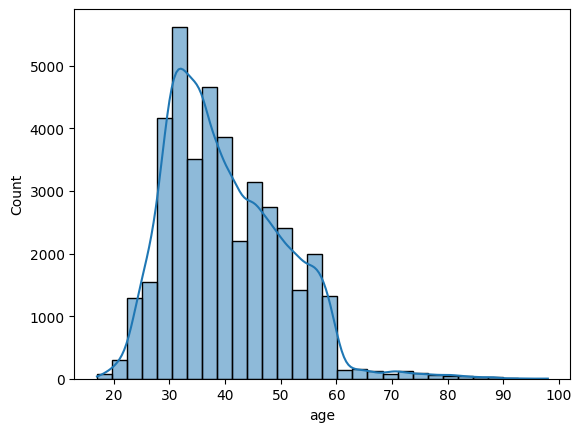

In [12]:
sns.histplot(data=df,x='age',bins=30,kde=True)

In [18]:
X = pd.get_dummies(df)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2,random_state=101)

In [38]:
predictions = model.fit_predict(X_scaled)

In [39]:
predictions

array([1, 1, 1, ..., 0, 0, 0], shape=(41188,), dtype=int32)

In [40]:
np.unique(predictions)

array([0, 1], dtype=int32)

In [42]:
X['cluster'] = predictions

<Axes: >

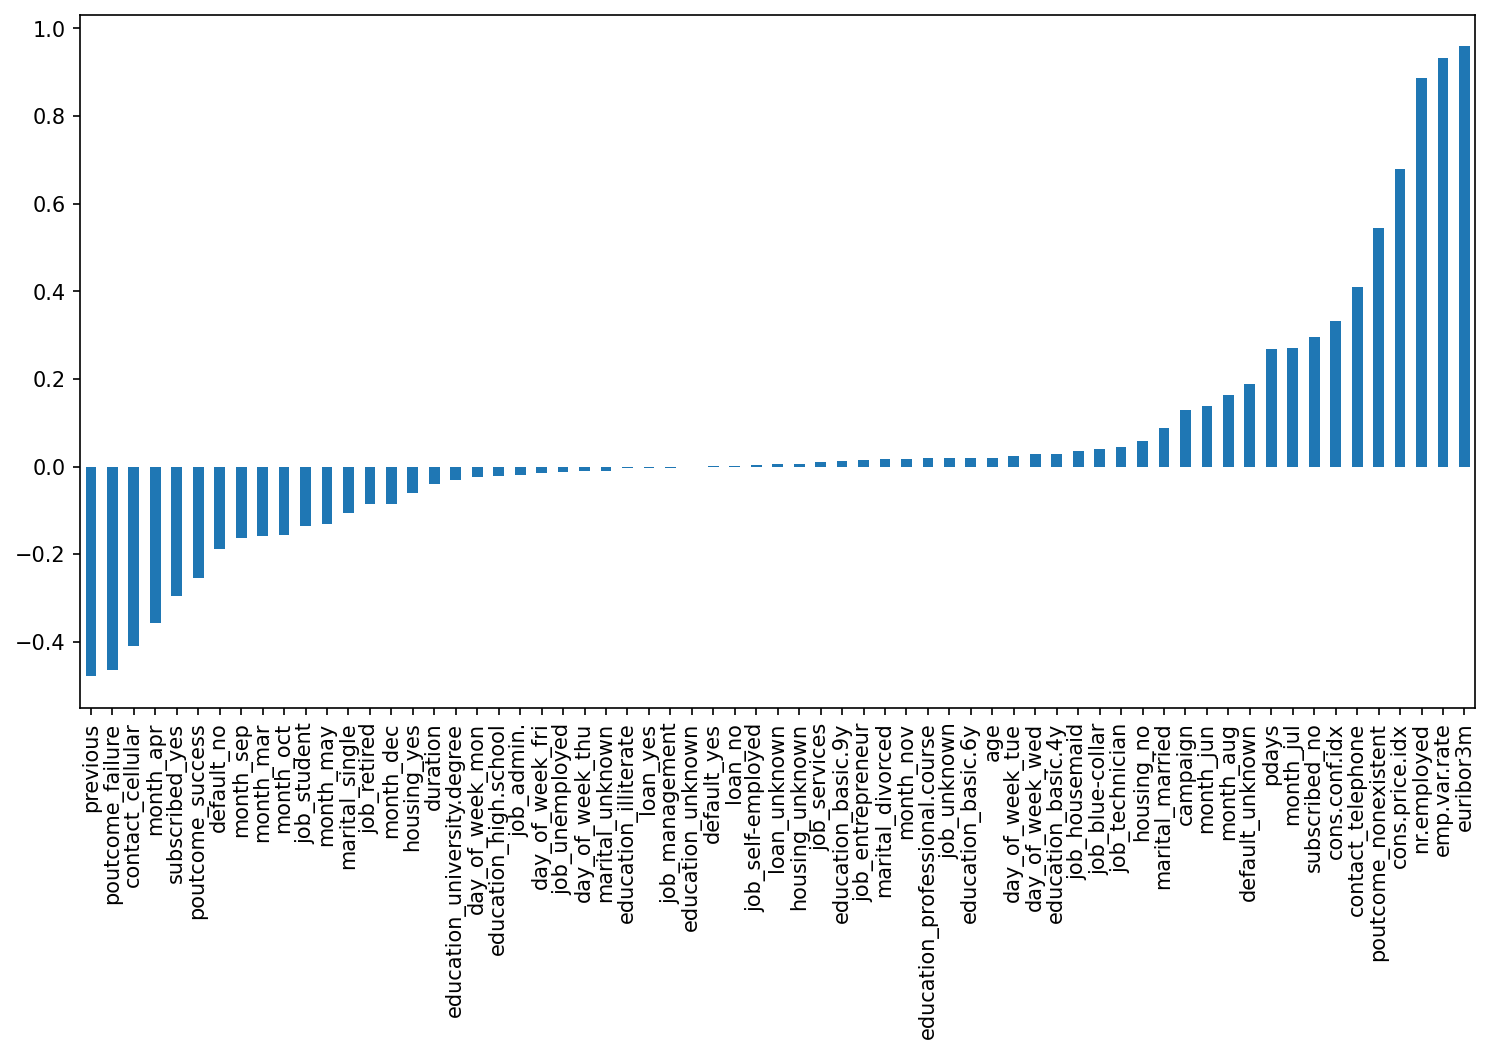

In [53]:
plt.figure(figsize=(12,6),dpi=150)
X.corr()['cluster'].iloc[:-1].sort_values().plot(kind='bar')

<Axes: xlabel='previous', ylabel='previous'>

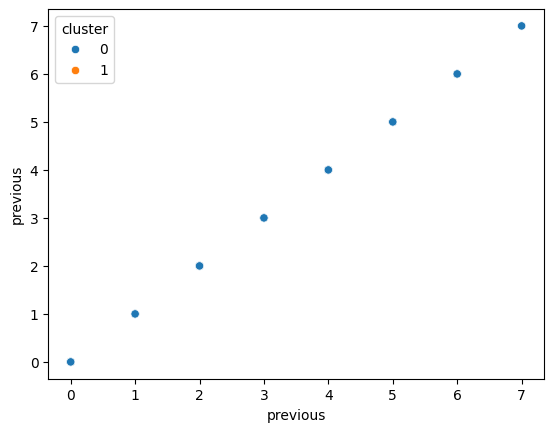

In [56]:
sns.scatterplot(data=X,x='previous',y='previous',hue='cluster')

In [58]:
ssd = []

for k in range(2,10):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    ssd.append(model.inertia_)

In [60]:
len(ssd),len(range(2,10))

[2469792.3788124025,
 2382895.7994419197,
 2329126.46370841,
 2291214.576912272,
 2159572.5723594995,
 2123416.2732330044,
 2093652.2034899043,
 2073412.282488616]

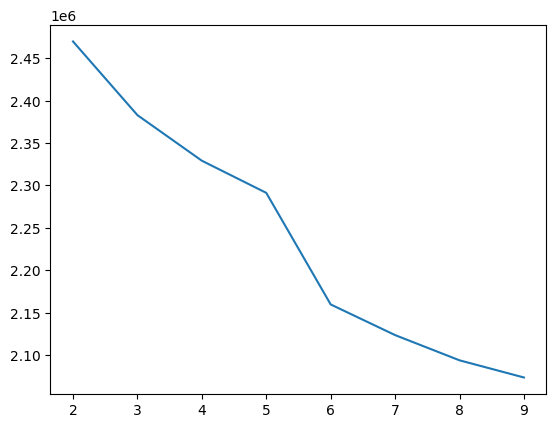

In [65]:
plt.plot(range(2,10),ssd)

In [66]:
ssd_s = pd.Series(ssd)

In [68]:
ssd_s.diff()

0              NaN
1    -86896.579370
2    -53769.335734
3    -37911.886796
4   -131642.004553
5    -36156.299126
6    -29764.069743
7    -20239.921001
dtype: float64

In [69]:
import matplotlib.image as mpimg

In [71]:
image_as_array = mpimg.imread('../../Excercises/DATA/palm_trees.jpg')

In [ ]:
# 934 X 1401

In [92]:
image_as_array[0].shape

(934, 3)

In [94]:
image_as_array.shape

(1401, 934, 3)

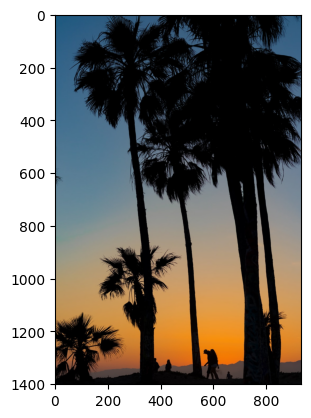

In [98]:
plt.imshow(image_as_array)

In [99]:
(h,w,c) = image_as_array.shape

In [100]:
image_as_array2d = image_as_array.reshape(h*w,c)

In [103]:
image_as_array2d.shape

(1308534, 3)

In [104]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=6)

In [105]:
preds = model.fit_predict(image_as_array2d)

In [109]:
rgb_codes = model.cluster_centers_.round(0).astype(int)

In [120]:
preds

array([2, 2, 2, ..., 1, 1, 1], shape=(1308534,), dtype=int32)

In [114]:
quantized_image = np.reshape(rgb_codes[preds],(h,w,c))

In [117]:
# image_as_array2d
quantized_image

array([[[ 71, 109, 138],
        [ 71, 109, 138],
        [ 71, 109, 138],
        ...,
        [ 67,  62,  62],
        [ 71, 109, 138],
        [ 71, 109, 138]],

       [[ 71, 109, 138],
        [ 71, 109, 138],
        [ 71, 109, 138],
        ...,
        [ 67,  62,  62],
        [ 71, 109, 138],
        [ 71, 109, 138]],

       [[ 71, 109, 138],
        [ 71, 109, 138],
        [ 71, 109, 138],
        ...,
        [ 71, 109, 138],
        [ 71, 109, 138],
        [ 71, 109, 138]],

       ...,

       [[  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4],
        ...,
        [  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4]],

       [[  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4],
        ...,
        [  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4]],

       [[  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4],
        ...,
        [  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4]]

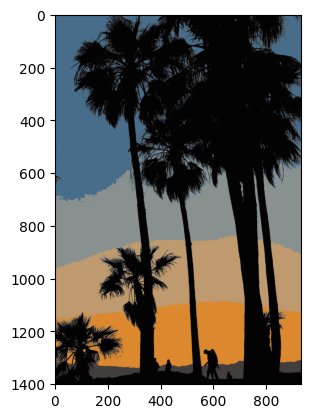

In [118]:
plt.imshow(quantized_image)